In [1]:
# Block 1: Install packages
!pip install -q pandas numpy matplotlib seaborn scikit-learn openpyxl semopy xgboost shap torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 6.4 MB/s eta 0:00:00


In [2]:
# Block 2: Upload and read the questionnaire file
import pandas as pd
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)
df.head()

Saving Evaluation of Smart Construction Infrastructure and Autonomous Technologies in a Virtual Reality Environment (Responses) (1).xlsx to Evaluation of Smart Construction Infrastructure and Autonomous Technologies in a Virtual Reality Environment (Responses) (1).xlsx


,Timestamp,A1. Participant Name,A2. Age Group,A3. Gender,A4. Highest Educational Qualification,A5. Previous VR Experience,A6. Construction Industry Experience,A7. Scenario ID,SA1. I was aware of the construction activities occurring around me.,SA2. I clearly understood the construction site layout and operational zones.,...,PS3. I felt protected from potential hazards during the VR experience.,AI1. I intend to use smart construction infrastructure in my future projects.,AI2. I plan to recommend smart construction infrastructure to my colleagues.,AI3. I am willing to invest in smart construction infrastructure for my projects.,ES1. I actively engage with new technologies used in construction projects.,ES2. I support the adoption of autonomous technologies in the construction industry.,ES3. I believe smart construction technologies will improve overall project outcomes.,AF1. What aspects of the VR experience did you find most valuable or engaging?,AF2. Do you have any suggestions for improving the smart construction infrastructure or the VR simulation experience?,Email Address
0,2026-06-27 15:03:40.801,Shreyaa,18–25,Female,Bachelor's Degree,Occassionally,No Experience,NaN,5,4,...,6,7,7,7,7,7,7,Nil,Nil,NaN
1,2026-06-27 15:16:05.748,Q,18–25,Female,Bachelor's Degree,Never,No Experience,NaN,7,6,...,7,7,7,7,5,6,7,"Safe interaction, due to high-quality visual a...",AI realistic simulaton and multiple user handl...,NaN
2,2026-06-27 17:44:58.221,Rohan Charcha,18–25,Male,Bachelor's Degree,Frequently,No Experience,NaN,3,3,...,4,2,2,1,4,1,6,Yes,No.,NaN
3,2026-06-27 20:39:20.217,Bismita Sahu,18–25,Male,Bachelor's Degree,Never,No Experience,NaN,1,2,...,6,7,1,2,3,4,5,Construction site was intresting,No,NaN
4,2026-06-27 20:41:15.182,Sujal Pradhan,18–25,Male,Bachelor's Degree,Occassionally,Less than 2 Years,NaN,1,2,...,4,3,4,5,6,7,6,Finding hazards were intresting,No,NaN


In [3]:
# Block 3: Rename columns and prepare SEM dataset
rename = {}
for c in df.columns:
    lc = str(c).lower()
    if 'age group' in lc: rename[c] = 'AgeGroup'
    elif 'gender' in lc and 'highest' not in lc: rename[c] = 'Gender'
    elif 'highest educational qualification' in lc: rename[c] = 'Education'
    elif 'previous vr experience' in lc: rename[c] = 'VRExperience'
    elif 'construction industry experience' in lc: rename[c] = 'ConstructionExperience'
    elif 'scenario id' in lc: rename[c] = 'ScenarioID'
    elif lc.startswith('sa1'): rename[c] = 'SA1'
    elif lc.startswith('sa2'): rename[c] = 'SA2'
    elif lc.startswith('sa3'): rename[c] = 'SA3'
    elif lc.startswith('tr2'): rename[c] = 'TR1'
    elif lc.startswith('tr3'): rename[c] = 'TR2'
    elif lc.startswith('tr4'): rename[c] = 'TR3'
    elif lc.startswith('ps1'): rename[c] = 'PS1'
    elif lc.startswith('ps2'): rename[c] = 'PS2'
    elif lc.startswith('ps3'): rename[c] = 'PS3'
    elif lc.startswith('ai1'): rename[c] = 'AI1'
    elif lc.startswith('ai2'): rename[c] = 'AI2'
    elif lc.startswith('ai3'): rename[c] = 'AI3'
    elif lc.startswith('es1'): rename[c] = 'ES1'
    elif lc.startswith('es2'): rename[c] = 'ES2'
    elif lc.startswith('es3'): rename[c] = 'ES3'

df = df.rename(columns=rename)

sem_cols = ['SA1','SA2','SA3','TR1','TR2','TR3','PS1','PS2','PS3','AI1','AI2','AI3','ES1','ES2','ES3']
for c in sem_cols + ['ScenarioID']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

sem_df = df[sem_cols].dropna().copy()
sem_df.head()

,SA1,SA2,SA3,TR1,TR2,TR3,PS1,PS2,PS3,AI1,AI2,AI3,ES1,ES2,ES3
0,5,4,4,7,6,6.0,6,6,6,7,7,7,7,7,7
2,3,3,4,1,1,1.0,1,4,4,2,2,1,4,1,6
3,1,2,1,1,2,3.0,4,5,6,7,1,2,3,4,5
4,1,2,3,4,5,6.0,7,1,4,3,4,5,6,7,6
5,5,6,7,5,6,7.0,5,6,7,5,6,7,5,6,7


In [4]:
# Block 4: Reliability analysis
import numpy as np

def cronbach_alpha(items_df):
    items = items_df.dropna().to_numpy(dtype=float)
    k = items.shape[1]
    item_var = items.var(axis=0, ddof=1)
    total_var = items.sum(axis=1).var(ddof=1)
    return (k/(k-1)) * (1 - item_var.sum()/total_var)

constructs = {
    'SA':['SA1','SA2','SA3'],
    'TR':['TR1','TR2','TR3'],
    'PS':['PS1','PS2','PS3'],
    'AI':['AI1','AI2','AI3'],
    'ES':['ES1','ES2','ES3']
}

rows = []
for k, items in constructs.items():
    alpha = cronbach_alpha(sem_df[items])
    score = sem_df[items].mean(axis=1)
    loadings = [sem_df[i].corr(score) for i in items]
    ave = np.mean(np.square(loadings))
    cr = (np.sum(loadings)**2)/((np.sum(loadings)**2)+np.sum(1-np.square(loadings)))
    rows.append([k, alpha, cr, ave])

rel_df = pd.DataFrame(rows, columns=['Construct','CronbachAlpha','CompositeReliability','AVE'])
rel_df

,Construct,CronbachAlpha,CompositeReliability,AVE
0,SA,0.859609,0.916039,0.784539
1,TR,0.852637,0.911861,0.775228
2,PS,0.490992,0.745582,0.498676
3,AI,0.833256,0.904397,0.759269
4,ES,0.638241,0.805815,0.580807


In [8]:
# === CLEANUP BLOCK: manual item pruning + re-evaluation ===

import pandas as pd
import numpy as np

# Assumes sem_df and constructs already exist

def cronbach_alpha(items_df):
    items = items_df.dropna().to_numpy(dtype=float)
    k = items.shape[1]
    item_var = items.var(axis=0, ddof=1)
    total_var = items.sum(axis=1).var(ddof=1)
    return (k/(k-1)) * (1 - item_var.sum()/total_var)

def construct_stats(data, construct_map):
    rows = []
    scores = pd.DataFrame(index=data.index)
    for con, items in construct_map.items():
        scores[con] = data[items].mean(axis=1)
        alpha = cronbach_alpha(data[items])
        loadings = [data[i].corr(scores[con]) for i in items]
        cr = (np.sum(loadings)**2)/((np.sum(loadings)**2)+np.sum(1-np.square(loadings)))
        ave = np.mean(np.square(loadings))
        rows.append([con, alpha, cr, ave, loadings])
    return pd.DataFrame(rows, columns=['Construct','Alpha','CR','AVE','Loadings']), scores

def htmt_matrix(data, construct_map):
    names = list(construct_map.keys())
    corr = data.corr().abs()
    out = pd.DataFrame(np.ones((len(names), len(names))), index=names, columns=names)
    for i, a in enumerate(names):
        for j, b in enumerate(names):
            if i >= j:
                continue
            ia, ib = construct_map[a], construct_map[b]
            hetero = corr.loc[ia, ib].values.flatten().mean()
            mono_a = corr.loc[ia, ia].values
            mono_a = mono_a[np.triu_indices_from(mono_a, k=1)].mean()
            mono_b = corr.loc[ib, ib].values
            mono_b = mono_b[np.triu_indices_from(mono_b, k=1)].mean()
            out.loc[a, b] = hetero / np.sqrt(mono_a * mono_b)
            out.loc[b, a] = out.loc[a, b]
    return out

# Baseline
base_stats, base_scores = construct_stats(sem_df, constructs)
base_htmt = htmt_matrix(sem_df, constructs)

print("=== BASELINE SUMMARY ===")
display(base_stats[['Construct','Alpha','CR','AVE']].round(3))
print("\n=== BASELINE HTMT ===")
display(base_htmt.round(3))

# Try a manual PS revision first
trial_constructs = {k: v[:] for k, v in constructs.items()}
trial_constructs['PS'] = ['PS2', 'PS3']   # drop PS1 first

trial_stats, trial_scores = construct_stats(sem_df, trial_constructs)
trial_htmt = htmt_matrix(sem_df, trial_constructs)

print("\n=== TRIAL SUMMARY (PS1 removed) ===")
display(trial_stats[['Construct','Alpha','CR','AVE']].round(3))
print("\n=== TRIAL HTMT (PS1 removed) ===")
display(trial_htmt.round(3))

# Compare PS before/after
base_ps = base_stats[base_stats['Construct'] == 'PS'].iloc[0]
trial_ps = trial_stats[trial_stats['Construct'] == 'PS'].iloc[0]

compare = pd.DataFrame([
    ['Original PS', base_ps['Alpha'], base_ps['CR'], base_ps['AVE']],
    ['PS without PS1', trial_ps['Alpha'], trial_ps['CR'], trial_ps['AVE']]
], columns=['Version','Alpha','CR','AVE'])

print("\n=== PS COMPARISON ===")
display(compare.round(3))

# Export
base_stats[['Construct','Alpha','CR','AVE']].to_csv('baseline_construct_stats.csv', index=False)
trial_stats[['Construct','Alpha','CR','AVE']].to_csv('trial_construct_stats_ps1_removed.csv', index=False)
trial_htmt.to_csv('trial_htmt_ps1_removed.csv')
compare.to_csv('ps_compare_original_vs_trial.csv', index=False)

print("\nSaved:")
print("- baseline_construct_stats.csv")
print("- trial_construct_stats_ps1_removed.csv")
print("- trial_htmt_ps1_removed.csv")
print("- ps_compare_original_vs_trial.csv")

=== BASELINE SUMMARY ===


,Construct,Alpha,CR,AVE
0,SA,0.860,0.916,0.785
1,TR,0.853,0.912,0.775
2,PS,0.491,0.746,0.499
3,AI,0.833,0.904,0.759
4,ES,0.638,0.806,0.581



=== BASELINE HTMT ===


,SA,TR,PS,AI,ES
SA,1.000,0.948,1.157,0.996,0.937
TR,0.948,1.000,1.286,1.054,1.119
PS,1.157,1.286,1.000,1.257,1.178
AI,0.996,1.054,1.257,1.000,1.176
ES,0.937,1.119,1.178,1.176,1.000



=== TRIAL SUMMARY (PS1 removed) ===


...


=== TRIAL HTMT (PS1 removed) ===


,SA,TR,PS,AI,ES
SA,1.000,0.948,1.067,0.996,0.937
TR,0.948,1.000,0.961,1.054,1.119
PS,1.067,0.961,1.000,1.067,0.890
AI,0.996,1.054,1.067,1.000,1.176
ES,0.937,1.119,0.890,1.176,1.000



=== PS COMPARISON ===


,Version,Alpha,CR,AVE
0,Original PS,0.491,0.746,0.499
1,PS without PS1,0.522,0.807,0.676



Saved:
- baseline_construct_stats.csv
- trial_construct_stats_ps1_removed.csv
- trial_htmt_ps1_removed.csv
- ps_compare_original_vs_trial.csv


In [9]:
# === BLOCK 5: Full single-item search across all constructs ===

import pandas as pd
import numpy as np

# Assumes sem_df and constructs already exist

def cronbach_alpha(items_df):
    items = items_df.dropna().to_numpy(dtype=float)
    k = items.shape[1]
    item_var = items.var(axis=0, ddof=1)
    total_var = items.sum(axis=1).var(ddof=1)
    return (k/(k-1)) * (1 - item_var.sum()/total_var)

def stats_for_map(data, cmap):
    rows = []
    for con, items in cmap.items():
        score = data[items].mean(axis=1)
        loadings = [data[i].corr(score) for i in items]
        alpha = cronbach_alpha(data[items])
        cr = (np.sum(loadings)**2)/((np.sum(loadings)**2)+np.sum(1-np.square(loadings)))
        ave = np.mean(np.square(loadings))
        rows.append([con, alpha, cr, ave, loadings])
    return pd.DataFrame(rows, columns=['Construct','Alpha','CR','AVE','Loadings'])

def htmt_matrix(data, cmap):
    names = list(cmap.keys())
    corr = data.corr().abs()
    out = pd.DataFrame(np.ones((len(names), len(names))), index=names, columns=names)
    for i, a in enumerate(names):
        for j, b in enumerate(names):
            if i >= j:
                continue
            ia, ib = cmap[a], cmap[b]
            hetero = corr.loc[ia, ib].values.flatten().mean()
            mono_a = corr.loc[ia, ia].values
            mono_a = mono_a[np.triu_indices_from(mono_a, k=1)].mean()
            mono_b = corr.loc[ib, ib].values
            mono_b = mono_b[np.triu_indices_from(mono_b, k=1)].mean()
            out.loc[a, b] = hetero / np.sqrt(mono_a * mono_b)
            out.loc[b, a] = out.loc[a, b]
    return out

rows = []
for con, items in constructs.items():
    if len(items) <= 2:
        continue
    for drop in items:
        trial = {k: v[:] for k, v in constructs.items()}
        trial[con] = [x for x in items if x != drop]
        try:
            tmp = sem_df[sum(trial.values(), [])].dropna().copy()
            rel = stats_for_map(tmp, trial)
            ht = htmt_matrix(tmp, trial)
            max_htmt = ht.replace(1, np.nan).max().max()
            target = rel[rel['Construct'] == con].iloc[0]
            rows.append([
                con, drop, len(trial[con]),
                round(target['Alpha'], 3),
                round(target['CR'], 3),
                round(target['AVE'], 3),
                round(max_htmt, 3)
            ])
        except Exception as e:
            rows.append([con, drop, len(items)-1, None, None, None, None])

result = pd.DataFrame(rows, columns=['Construct','DroppedItem','RemainingItems','Alpha','CR','AVE','MaxHTMT'])

print("=== SINGLE-ITEM DROP SEARCH ===")
display(result.sort_values(['AVE','CR'], ascending=False))

print("\n=== BEST BY CONSTRUCT ===")
best = result.sort_values(['Construct','AVE','MaxHTMT'], ascending=[True, False, True]).groupby('Construct').head(1)
display(best)

result.to_csv('single_item_drop_search.csv', index=False)
best.to_csv('single_item_drop_best.csv', index=False)

print("\nSaved:")
print("- single_item_drop_search.csv")
print("- single_item_drop_best.csv")

=== SINGLE-ITEM DROP SEARCH ===


,Construct,DroppedItem,RemainingItems,Alpha,CR,AVE,MaxHTMT
0,SA,SA1,2,0.861,0.935,0.879,1.286
2,SA,SA3,2,0.834,0.924,0.859,1.286
3,TR,TR1,2,0.810,0.916,0.844,1.279
9,AI,AI1,2,0.793,0.913,0.840,1.286
5,TR,TR3,2,0.787,0.905,0.826,1.257
4,TR,TR2,2,0.785,0.903,0.824,1.325
11,AI,AI3,2,0.779,0.903,0.823,1.286
10,AI,AI2,2,0.739,0.886,0.795,1.372
1,SA,SA2,2,0.711,0.874,0.776,1.286
14,ES,ES3,2,0.607,0.836,0.719,1.286



=== BEST BY CONSTRUCT ===


,Construct,DroppedItem,RemainingItems,Alpha,CR,AVE,MaxHTMT
9,AI,AI1,2,0.793,0.913,0.840,1.286
14,ES,ES3,2,0.607,0.836,0.719,1.286
6,PS,PS1,2,0.522,0.807,0.676,1.176
0,SA,SA1,2,0.861,0.935,0.879,1.286
3,TR,TR1,2,0.810,0.916,0.844,1.279



Saved:
- single_item_drop_search.csv
- single_item_drop_best.csv


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('output', exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.05)

In [11]:
base = pd.DataFrame([
    ['SA',0.860,0.916,0.785],
    ['TR',0.853,0.912,0.775],
    ['PS',0.491,0.746,0.499],
    ['AI',0.833,0.904,0.759],
    ['ES',0.638,0.806,0.581],
], columns=['Construct','Alpha','CR','AVE'])

trial = pd.DataFrame([
    ['SA',0.860,0.916,0.785],
    ['TR',0.853,0.912,0.775],
    ['PS',0.522,0.807,0.676],
    ['AI',0.833,0.904,0.759],
    ['ES',0.638,0.806,0.581],
], columns=['Construct','Alpha','CR','AVE'])

compare = pd.DataFrame([
    ['Original PS',0.491,0.746,0.499],
    ['PS without PS1',0.522,0.807,0.676]
], columns=['Version','Alpha','CR','AVE'])

htmt = pd.DataFrame([
    [1.000,0.948,1.067,0.996,0.937],
    [0.948,1.000,0.961,1.054,1.119],
    [1.067,0.961,1.000,1.067,0.890],
    [0.996,1.054,1.067,1.000,1.176],
    [0.937,1.119,0.890,1.176,1.000],
], columns=['SA','TR','PS','AI','ES'], index=['SA','TR','PS','AI','ES'])

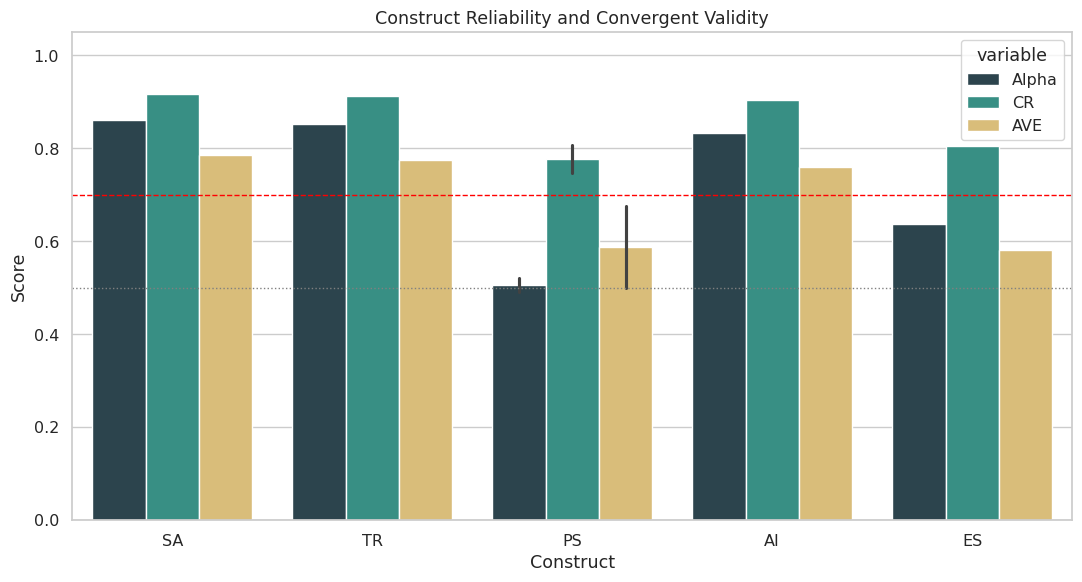

In [12]:
plot_df = pd.concat([base.assign(Version='Baseline'), trial.assign(Version='PS1 removed')], ignore_index=True)
plot_df = plot_df.melt(id_vars=['Construct','Version'], value_vars=['Alpha','CR','AVE'])

plt.figure(figsize=(11,6))
sns.barplot(data=plot_df, x='Construct', y='value', hue='variable',
            palette=['#264653','#2a9d8f','#e9c46a'])
plt.axhline(0.70, ls='--', c='red', lw=1)
plt.axhline(0.50, ls=':', c='gray', lw=1)
plt.ylim(0, 1.05)
plt.title('Construct Reliability and Convergent Validity')
plt.ylabel('Score')
plt.xlabel('Construct')
plt.tight_layout()
plt.show()

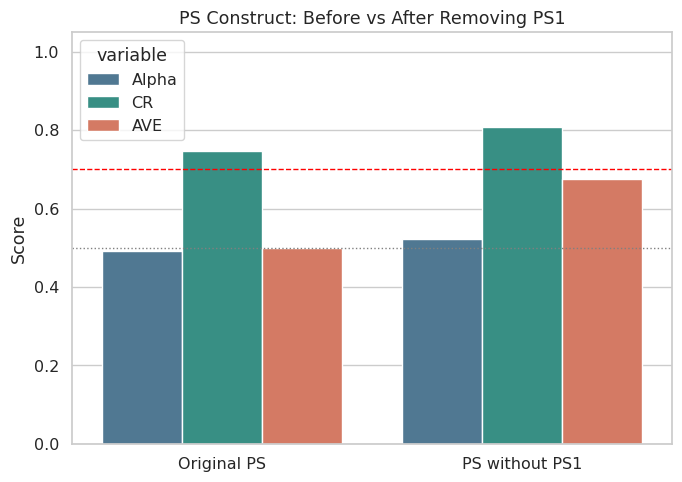

In [13]:
ps_cmp = compare.melt(id_vars='Version', value_vars=['Alpha','CR','AVE'])

plt.figure(figsize=(7,5))
sns.barplot(data=ps_cmp, x='Version', y='value', hue='variable',
            palette=['#457b9d','#2a9d8f','#e76f51'])
plt.axhline(0.70, ls='--', c='red', lw=1)
plt.axhline(0.50, ls=':', c='gray', lw=1)
plt.ylim(0, 1.05)
plt.title('PS Construct: Before vs After Removing PS1')
plt.ylabel('Score')
plt.xlabel('')
plt.tight_layout()
plt.show()

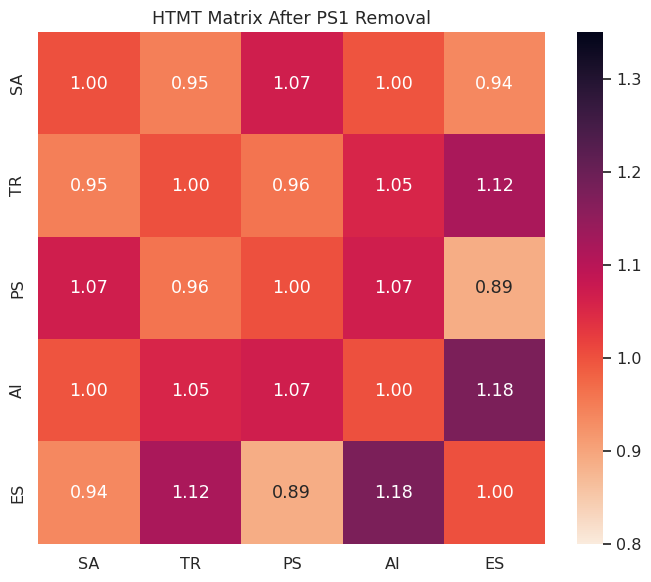

In [14]:
plt.figure(figsize=(7,6))
sns.heatmap(htmt.astype(float), annot=True, fmt='.2f', cmap='rocket_r',
            vmin=0.8, vmax=1.35)
plt.title('HTMT Matrix After PS1 Removal')
plt.tight_layout()
plt.show()

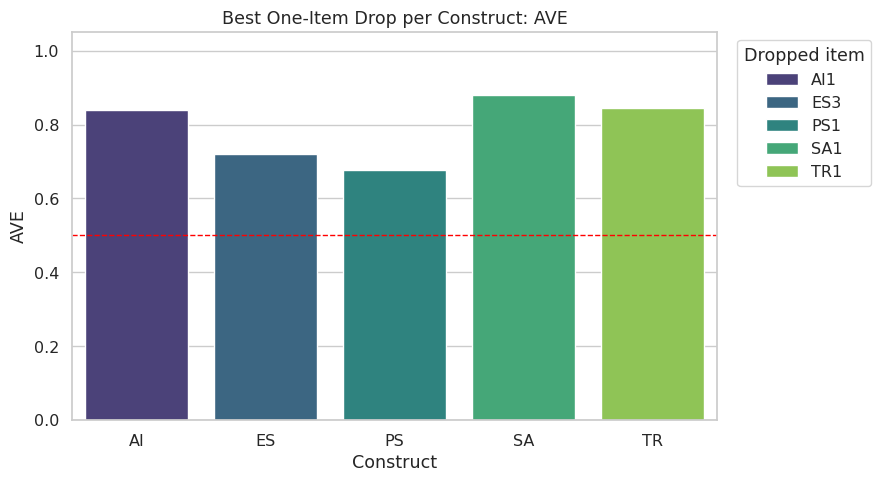

In [15]:
search = pd.DataFrame([
    ['SA','SA1',2,0.861,0.935,0.879,1.286],
    ['SA','SA3',2,0.834,0.924,0.859,1.286],
    ['TR','TR1',2,0.810,0.916,0.844,1.279],
    ['AI','AI1',2,0.793,0.913,0.840,1.286],
    ['TR','TR3',2,0.787,0.905,0.826,1.257],
    ['TR','TR2',2,0.785,0.903,0.824,1.325],
    ['AI','AI3',2,0.779,0.903,0.823,1.286],
    ['AI','AI2',2,0.739,0.886,0.795,1.372],
    ['SA','SA2',2,0.711,0.874,0.776,1.286],
    ['ES','ES3',2,0.607,0.836,0.719,1.286],
    ['ES','ES2',2,0.539,0.813,0.684,1.286],
    ['PS','PS1',2,0.522,0.807,0.676,1.176],
    ['PS','PS3',2,0.510,0.804,0.673,1.176],
    ['ES','ES1',2,0.464,0.789,0.651,1.367],
    ['PS','PS2',2,0.022,0.670,0.505,6.155],
], columns=['Construct','DroppedItem','RemainingItems','Alpha','CR','AVE','MaxHTMT'])

best = search.sort_values(['Construct','AVE'], ascending=[True, False]).groupby('Construct').head(1).copy()

plt.figure(figsize=(9,5))
sns.barplot(data=best, x='Construct', y='AVE', hue='DroppedItem', dodge=False, palette='viridis')
plt.axhline(0.50, ls='--', c='red', lw=1)
plt.ylim(0, 1.05)
plt.title('Best One-Item Drop per Construct: AVE')
plt.ylabel('AVE')
plt.xlabel('Construct')
plt.legend(title='Dropped item', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [16]:
plt.figure(figsize=(11,6))
sns.barplot(data=plot_df, x='Construct', y='value', hue='variable',
            palette=['#264653','#2a9d8f','#e9c46a'])
plt.axhline(0.70, ls='--', c='red', lw=1)
plt.axhline(0.50, ls=':', c='gray', lw=1)
plt.ylim(0, 1.05)
plt.title('Construct Reliability and Convergent Validity')
plt.tight_layout()
plt.savefig('output/reliability_comparison.png', dpi=220)
plt.close()

plt.figure(figsize=(7,5))
sns.barplot(data=ps_cmp, x='Version', y='value', hue='variable',
            palette=['#457b9d','#2a9d8f','#e76f51'])
plt.axhline(0.70, ls='--', c='red', lw=1)
plt.axhline(0.50, ls=':', c='gray', lw=1)
plt.ylim(0, 1.05)
plt.title('PS Construct: Before vs After Removing PS1')
plt.tight_layout()
plt.savefig('output/ps_before_after.png', dpi=220)
plt.close()

plt.figure(figsize=(7,6))
sns.heatmap(htmt.astype(float), annot=True, fmt='.2f', cmap='rocket_r',
            vmin=0.8, vmax=1.35)
plt.title('HTMT Matrix After PS1 Removal')
plt.tight_layout()
plt.savefig('output/htmt_ps1_removed.png', dpi=220)
plt.close()

plt.figure(figsize=(9,5))
sns.barplot(data=best, x='Construct', y='AVE', hue='DroppedItem', dodge=False, palette='viridis')
plt.axhline(0.50, ls='--', c='red', lw=1)
plt.ylim(0, 1.05)
plt.title('Best One-Item Drop per Construct: AVE')
plt.tight_layout()
plt.savefig('output/best_drop_ave.png', dpi=220)
plt.close()

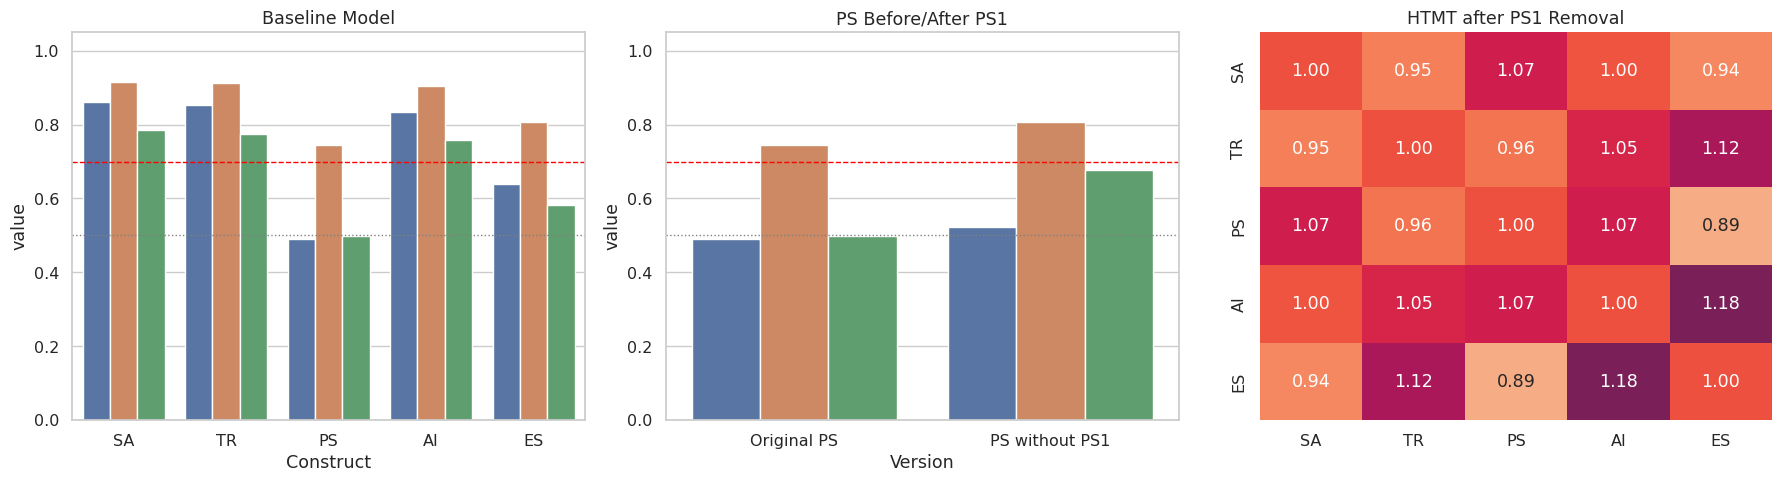

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

base_m = base.melt(id_vars='Construct', value_vars=['Alpha','CR','AVE'])
sns.barplot(data=base_m, x='Construct', y='value', hue='variable', ax=axes[0])
axes[0].set_title('Baseline Model')
axes[0].set_ylim(0,1.05)
axes[0].axhline(0.70, ls='--', c='red', lw=1)
axes[0].axhline(0.50, ls=':', c='gray', lw=1)
axes[0].legend_.remove()

sns.barplot(data=ps_cmp, x='Version', y='value', hue='variable', ax=axes[1])
axes[1].set_title('PS Before/After PS1')
axes[1].set_ylim(0,1.05)
axes[1].axhline(0.70, ls='--', c='red', lw=1)
axes[1].axhline(0.50, ls=':', c='gray', lw=1)
axes[1].legend_.remove()

sns.heatmap(htmt.astype(float), annot=True, fmt='.2f', cmap='rocket_r',
            ax=axes[2], cbar=False, vmin=0.8, vmax=1.35)
axes[2].set_title('HTMT after PS1 Removal')

plt.tight_layout()
plt.show()

NEW INIT

In [18]:
!pip install -q pandas numpy matplotlib seaborn openpyxl statsmodels

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set_theme(style='whitegrid', font_scale=1.05)

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)
df.head()

Saving Evaluation of Smart Construction Infrastructure and Autonomous Technologies in a Virtual Reality Environment (Responses) (1).xlsx to Evaluation of Smart Construction Infrastructure and Autonomous Technologies in a Virtual Reality Environment (Responses) (1) (2).xlsx


,Timestamp,A1. Participant Name,A2. Age Group,A3. Gender,A4. Highest Educational Qualification,A5. Previous VR Experience,A6. Construction Industry Experience,A7. Scenario ID,SA1. I was aware of the construction activities occurring around me.,SA2. I clearly understood the construction site layout and operational zones.,...,PS3. I felt protected from potential hazards during the VR experience.,AI1. I intend to use smart construction infrastructure in my future projects.,AI2. I plan to recommend smart construction infrastructure to my colleagues.,AI3. I am willing to invest in smart construction infrastructure for my projects.,ES1. I actively engage with new technologies used in construction projects.,ES2. I support the adoption of autonomous technologies in the construction industry.,ES3. I believe smart construction technologies will improve overall project outcomes.,AF1. What aspects of the VR experience did you find most valuable or engaging?,AF2. Do you have any suggestions for improving the smart construction infrastructure or the VR simulation experience?,Email Address
0,2026-06-27 15:03:40.801,Shreyaa,18–25,Female,Bachelor's Degree,Occassionally,No Experience,NaN,5,4,...,6,7,7,7,7,7,7,Nil,Nil,NaN
1,2026-06-27 15:16:05.748,Q,18–25,Female,Bachelor's Degree,Never,No Experience,NaN,7,6,...,7,7,7,7,5,6,7,"Safe interaction, due to high-quality visual a...",AI realistic simulaton and multiple user handl...,NaN
2,2026-06-27 17:44:58.221,Rohan Charcha,18–25,Male,Bachelor's Degree,Frequently,No Experience,NaN,3,3,...,4,2,2,1,4,1,6,Yes,No.,NaN
3,2026-06-27 20:39:20.217,Bismita Sahu,18–25,Male,Bachelor's Degree,Never,No Experience,NaN,1,2,...,6,7,1,2,3,4,5,Construction site was intresting,No,NaN
4,2026-06-27 20:41:15.182,Sujal Pradhan,18–25,Male,Bachelor's Degree,Occassionally,Less than 2 Years,NaN,1,2,...,4,3,4,5,6,7,6,Finding hazards were intresting,No,NaN


In [20]:
rename = {}
for c in df.columns:
    lc = str(c).lower().strip()
    if 'age group' in lc: rename[c] = 'AgeGroup'
    elif 'gender' in lc and 'highest' not in lc: rename[c] = 'Gender'
    elif 'highest educational qualification' in lc: rename[c] = 'Education'
    elif 'previous vr experience' in lc: rename[c] = 'VRExperience'
    elif 'construction industry experience' in lc: rename[c] = 'ConstructionExperience'
    elif 'scenario id' in lc: rename[c] = 'ScenarioID'
    elif lc.startswith('sa1'): rename[c] = 'SA1'
    elif lc.startswith('sa2'): rename[c] = 'SA2'
    elif lc.startswith('sa3'): rename[c] = 'SA3'
    elif lc.startswith('tr2'): rename[c] = 'TR1'
    elif lc.startswith('tr3'): rename[c] = 'TR2'
    elif lc.startswith('tr4'): rename[c] = 'TR3'
    elif lc.startswith('ps1'): rename[c] = 'PS1'
    elif lc.startswith('ps2'): rename[c] = 'PS2'
    elif lc.startswith('ps3'): rename[c] = 'PS3'
    elif lc.startswith('ai1'): rename[c] = 'AI1'
    elif lc.startswith('ai2'): rename[c] = 'AI2'
    elif lc.startswith('ai3'): rename[c] = 'AI3'
    elif lc.startswith('es1'): rename[c] = 'ES1'
    elif lc.startswith('es2'): rename[c] = 'ES2'
    elif lc.startswith('es3'): rename[c] = 'ES3'

df = df.rename(columns=rename)

constructs = {
    'SA':['SA1','SA2','SA3'],
    'TR':['TR1','TR2','TR3'],
    'PS':['PS1','PS2','PS3'],
    'AI':['AI1','AI2','AI3'],
    'ES':['ES1','ES2','ES3']
}

all_items = sum(constructs.values(), [])
sem_df = df[all_items].copy()

for c in all_items:
    sem_df[c] = pd.to_numeric(sem_df[c], errors='coerce')

sem_df = sem_df.dropna().reset_index(drop=True)
print("Sample size after cleaning:", len(sem_df))
sem_df.head()

Sample size after cleaning: 49


,SA1,SA2,SA3,TR1,TR2,TR3,PS1,PS2,PS3,AI1,AI2,AI3,ES1,ES2,ES3
0,5,4,4,7,6,6.0,6,6,6,7,7,7,7,7,7
1,3,3,4,1,1,1.0,1,4,4,2,2,1,4,1,6
2,1,2,1,1,2,3.0,4,5,6,7,1,2,3,4,5
3,1,2,3,4,5,6.0,7,1,4,3,4,5,6,7,6
4,5,6,7,5,6,7.0,5,6,7,5,6,7,5,6,7


In [21]:
def cronbach_alpha(items_df):
    items = items_df.dropna().to_numpy(dtype=float)
    k = items.shape[1]
    item_var = items.var(axis=0, ddof=1)
    total_var = items.sum(axis=1).var(ddof=1)
    return (k/(k-1)) * (1 - item_var.sum()/total_var)

def construct_stats(data, construct_map):
    rows = []
    scores = pd.DataFrame(index=data.index)
    for con, items in construct_map.items():
        scores[con] = data[items].mean(axis=1)
        alpha = cronbach_alpha(data[items])
        loadings = [data[i].corr(scores[con]) for i in items]
        cr = (np.sum(loadings)**2)/((np.sum(loadings)**2)+np.sum(1-np.square(loadings)))
        ave = np.mean(np.square(loadings))
        rows.append([con, alpha, cr, ave, loadings])
    return pd.DataFrame(rows, columns=['Construct','Alpha','CR','AVE','Loadings']), scores

def htmt_matrix(data, construct_map):
    names = list(construct_map.keys())
    corr = data.corr().abs()
    out = pd.DataFrame(np.ones((len(names), len(names))), index=names, columns=names)

    for i, a in enumerate(names):
        for j, b in enumerate(names):
            if i >= j:
                continue
            ia, ib = construct_map[a], construct_map[b]
            hetero = corr.loc[ia, ib].values.flatten().mean()
            mono_a = corr.loc[ia, ia].values
            mono_a = mono_a[np.triu_indices_from(mono_a, k=1)].mean()
            mono_b = corr.loc[ib, ib].values
            mono_b = mono_b[np.triu_indices_from(mono_b, k=1)].mean()
            out.loc[a, b] = hetero / np.sqrt(mono_a * mono_b)
            out.loc[b, a] = out.loc[a, b]
    return out

In [22]:
base_stats, base_scores = construct_stats(sem_df, constructs)
base_htmt = htmt_matrix(sem_df, constructs)

print("=== BASELINE SUMMARY ===")
display(base_stats[['Construct','Alpha','CR','AVE']].round(3))

print("=== BASELINE HTMT ===")
display(base_htmt.round(3))

=== BASELINE SUMMARY ===


,Construct,Alpha,CR,AVE
0,SA,0.860,0.916,0.785
1,TR,0.853,0.912,0.775
2,PS,0.491,0.746,0.499
3,AI,0.833,0.904,0.759
4,ES,0.638,0.806,0.581


=== BASELINE HTMT ===


,SA,TR,PS,AI,ES
SA,1.000,0.948,1.157,0.996,0.937
TR,0.948,1.000,1.286,1.054,1.119
PS,1.157,1.286,1.000,1.257,1.178
AI,0.996,1.054,1.257,1.000,1.176
ES,0.937,1.119,1.178,1.176,1.000


In [23]:
trial_constructs = {k: v[:] for k, v in constructs.items()}
trial_constructs['PS'] = ['PS2', 'PS3']   # remove PS1

trial_stats, trial_scores = construct_stats(sem_df, trial_constructs)
trial_htmt = htmt_matrix(sem_df, trial_constructs)

print("=== TRIAL SUMMARY (PS1 removed) ===")
display(trial_stats[['Construct','Alpha','CR','AVE']].round(3))

print("=== TRIAL HTMT (PS1 removed) ===")
display(trial_htmt.round(3))

=== TRIAL SUMMARY (PS1 removed) ===


,Construct,Alpha,CR,AVE
0,SA,0.860,0.916,0.785
1,TR,0.853,0.912,0.775
2,PS,0.522,0.807,0.676
3,AI,0.833,0.904,0.759
4,ES,0.638,0.806,0.581


=== TRIAL HTMT (PS1 removed) ===


,SA,TR,PS,AI,ES
SA,1.000,0.948,1.067,0.996,0.937
TR,0.948,1.000,0.961,1.054,1.119
PS,1.067,0.961,1.000,1.067,0.890
AI,0.996,1.054,1.067,1.000,1.176
ES,0.937,1.119,0.890,1.176,1.000


In [24]:
base_ps = base_stats[base_stats['Construct'] == 'PS'].iloc[0]
trial_ps = trial_stats[trial_stats['Construct'] == 'PS'].iloc[0]

compare = pd.DataFrame([
    ['Original PS', base_ps['Alpha'], base_ps['CR'], base_ps['AVE']],
    ['PS without PS1', trial_ps['Alpha'], trial_ps['CR'], trial_ps['AVE']]
], columns=['Version','Alpha','CR','AVE'])

display(compare.round(3))

,Version,Alpha,CR,AVE
0,Original PS,0.491,0.746,0.499
1,PS without PS1,0.522,0.807,0.676


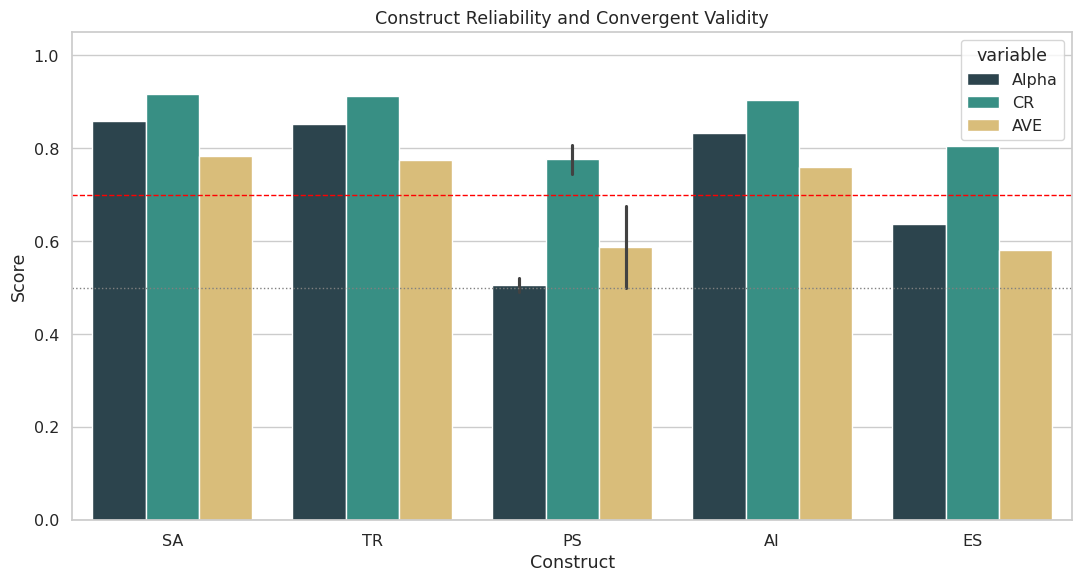

In [25]:
plot_df = pd.concat([
    base_stats[['Construct','Alpha','CR','AVE']].assign(Version='Baseline'),
    trial_stats[['Construct','Alpha','CR','AVE']].assign(Version='PS1 removed')
], ignore_index=True)

plot_df = plot_df.melt(id_vars=['Construct','Version'], value_vars=['Alpha','CR','AVE'])

plt.figure(figsize=(11,6))
sns.barplot(data=plot_df, x='Construct', y='value', hue='variable',
            palette=['#264653','#2a9d8f','#e9c46a'])
plt.axhline(0.70, ls='--', c='red', lw=1)
plt.axhline(0.50, ls=':', c='gray', lw=1)
plt.ylim(0, 1.05)
plt.title('Construct Reliability and Convergent Validity')
plt.ylabel('Score')
plt.xlabel('Construct')
plt.tight_layout()
plt.show()

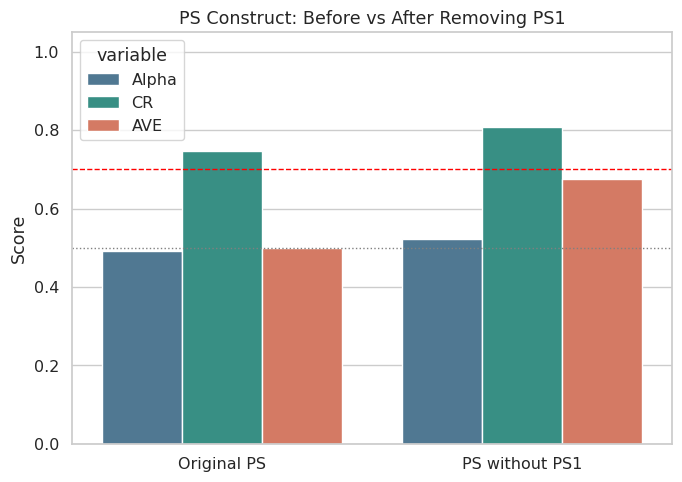

In [26]:
ps_cmp = compare.melt(id_vars='Version', value_vars=['Alpha','CR','AVE'])

plt.figure(figsize=(7,5))
sns.barplot(data=ps_cmp, x='Version', y='value', hue='variable',
            palette=['#457b9d','#2a9d8f','#e76f51'])
plt.axhline(0.70, ls='--', c='red', lw=1)
plt.axhline(0.50, ls=':', c='gray', lw=1)
plt.ylim(0, 1.05)
plt.title('PS Construct: Before vs After Removing PS1')
plt.ylabel('Score')
plt.xlabel('')
plt.tight_layout()
plt.show()

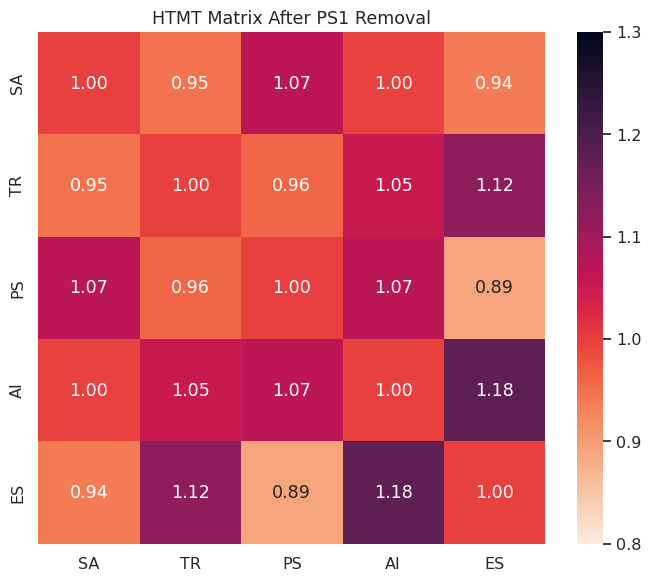

In [27]:
plt.figure(figsize=(7,6))
sns.heatmap(trial_htmt.astype(float), annot=True, fmt='.2f', cmap='rocket_r',
            vmin=0.8, vmax=max(1.3, float(np.nanmax(trial_htmt.values))))
plt.title('HTMT Matrix After PS1 Removal')
plt.tight_layout()
plt.show()

In [28]:
rows = []
for con, items in constructs.items():
    if len(items) <= 2:
        continue
    for drop in items:
        trial = {k: v[:] for k, v in constructs.items()}
        trial[con] = [x for x in items if x != drop]
        tmp = sem_df[sum(trial.values(), [])].dropna().copy()
        rel, _ = construct_stats(tmp, trial)
        ht = htmt_matrix(tmp, trial)
        max_htmt = ht.replace(1, np.nan).max().max()
        target = rel[rel['Construct'] == con].iloc[0]
        rows.append([
            con, drop, len(trial[con]),
            round(target['Alpha'], 3),
            round(target['CR'], 3),
            round(target['AVE'], 3),
            round(max_htmt, 3)
        ])

search = pd.DataFrame(rows, columns=['Construct','DroppedItem','RemainingItems','Alpha','CR','AVE','MaxHTMT'])
display(search.sort_values(['Construct','AVE'], ascending=[True, False]))

,Construct,DroppedItem,RemainingItems,Alpha,CR,AVE,MaxHTMT
9,AI,AI1,2,0.793,0.913,0.840,1.286
11,AI,AI3,2,0.779,0.903,0.823,1.286
10,AI,AI2,2,0.739,0.886,0.795,1.372
14,ES,ES3,2,0.607,0.836,0.719,1.286
13,ES,ES2,2,0.539,0.813,0.684,1.286
12,ES,ES1,2,0.464,0.789,0.651,1.367
6,PS,PS1,2,0.522,0.807,0.676,1.176
8,PS,PS3,2,0.510,0.804,0.673,1.176
7,PS,PS2,2,0.022,0.670,0.505,6.155
0,SA,SA1,2,0.861,0.935,0.879,1.286


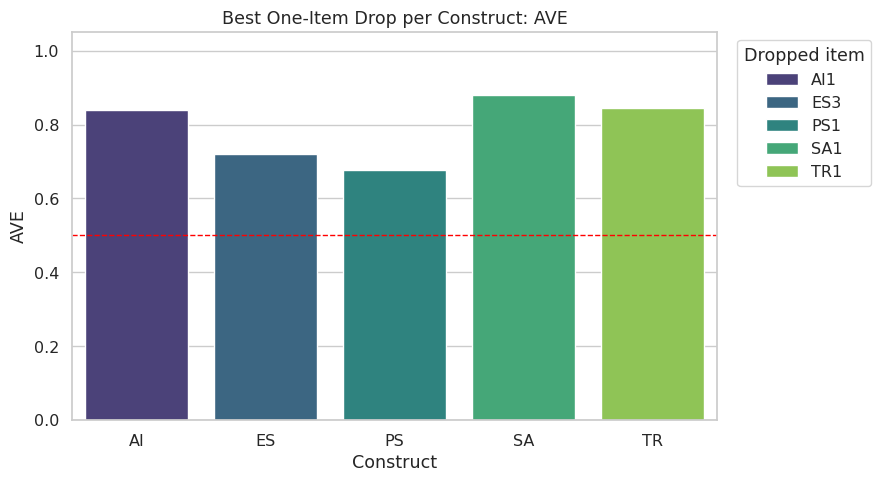

In [29]:
best = search.sort_values(['Construct','AVE'], ascending=[True, False]).groupby('Construct').head(1).copy()

plt.figure(figsize=(9,5))
sns.barplot(data=best, x='Construct', y='AVE', hue='DroppedItem', dodge=False, palette='viridis')
plt.axhline(0.50, ls='--', c='red', lw=1)
plt.ylim(0, 1.05)
plt.title('Best One-Item Drop per Construct: AVE')
plt.ylabel('AVE')
plt.xlabel('Construct')
plt.legend(title='Dropped item', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [30]:
base_stats[['Construct','Alpha','CR','AVE']].to_csv('baseline_construct_stats.csv', index=False)
trial_stats[['Construct','Alpha','CR','AVE']].to_csv('trial_construct_stats_ps1_removed.csv', index=False)
trial_htmt.to_csv('trial_htmt_ps1_removed.csv')
compare.to_csv('ps_compare_original_vs_trial.csv', index=False)
search.to_csv('single_item_drop_search.csv', index=False)

print("Saved files:")
print("- baseline_construct_stats.csv")
print("- trial_construct_stats_ps1_removed.csv")
print("- trial_htmt_ps1_removed.csv")
print("- ps_compare_original_vs_trial.csv")
print("- single_item_drop_search.csv")

Saved files:
- baseline_construct_stats.csv
- trial_construct_stats_ps1_removed.csv
- trial_htmt_ps1_removed.csv
- ps_compare_original_vs_trial.csv
- single_item_drop_search.csv


/tmp/ipykernel_13000/3092708711.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


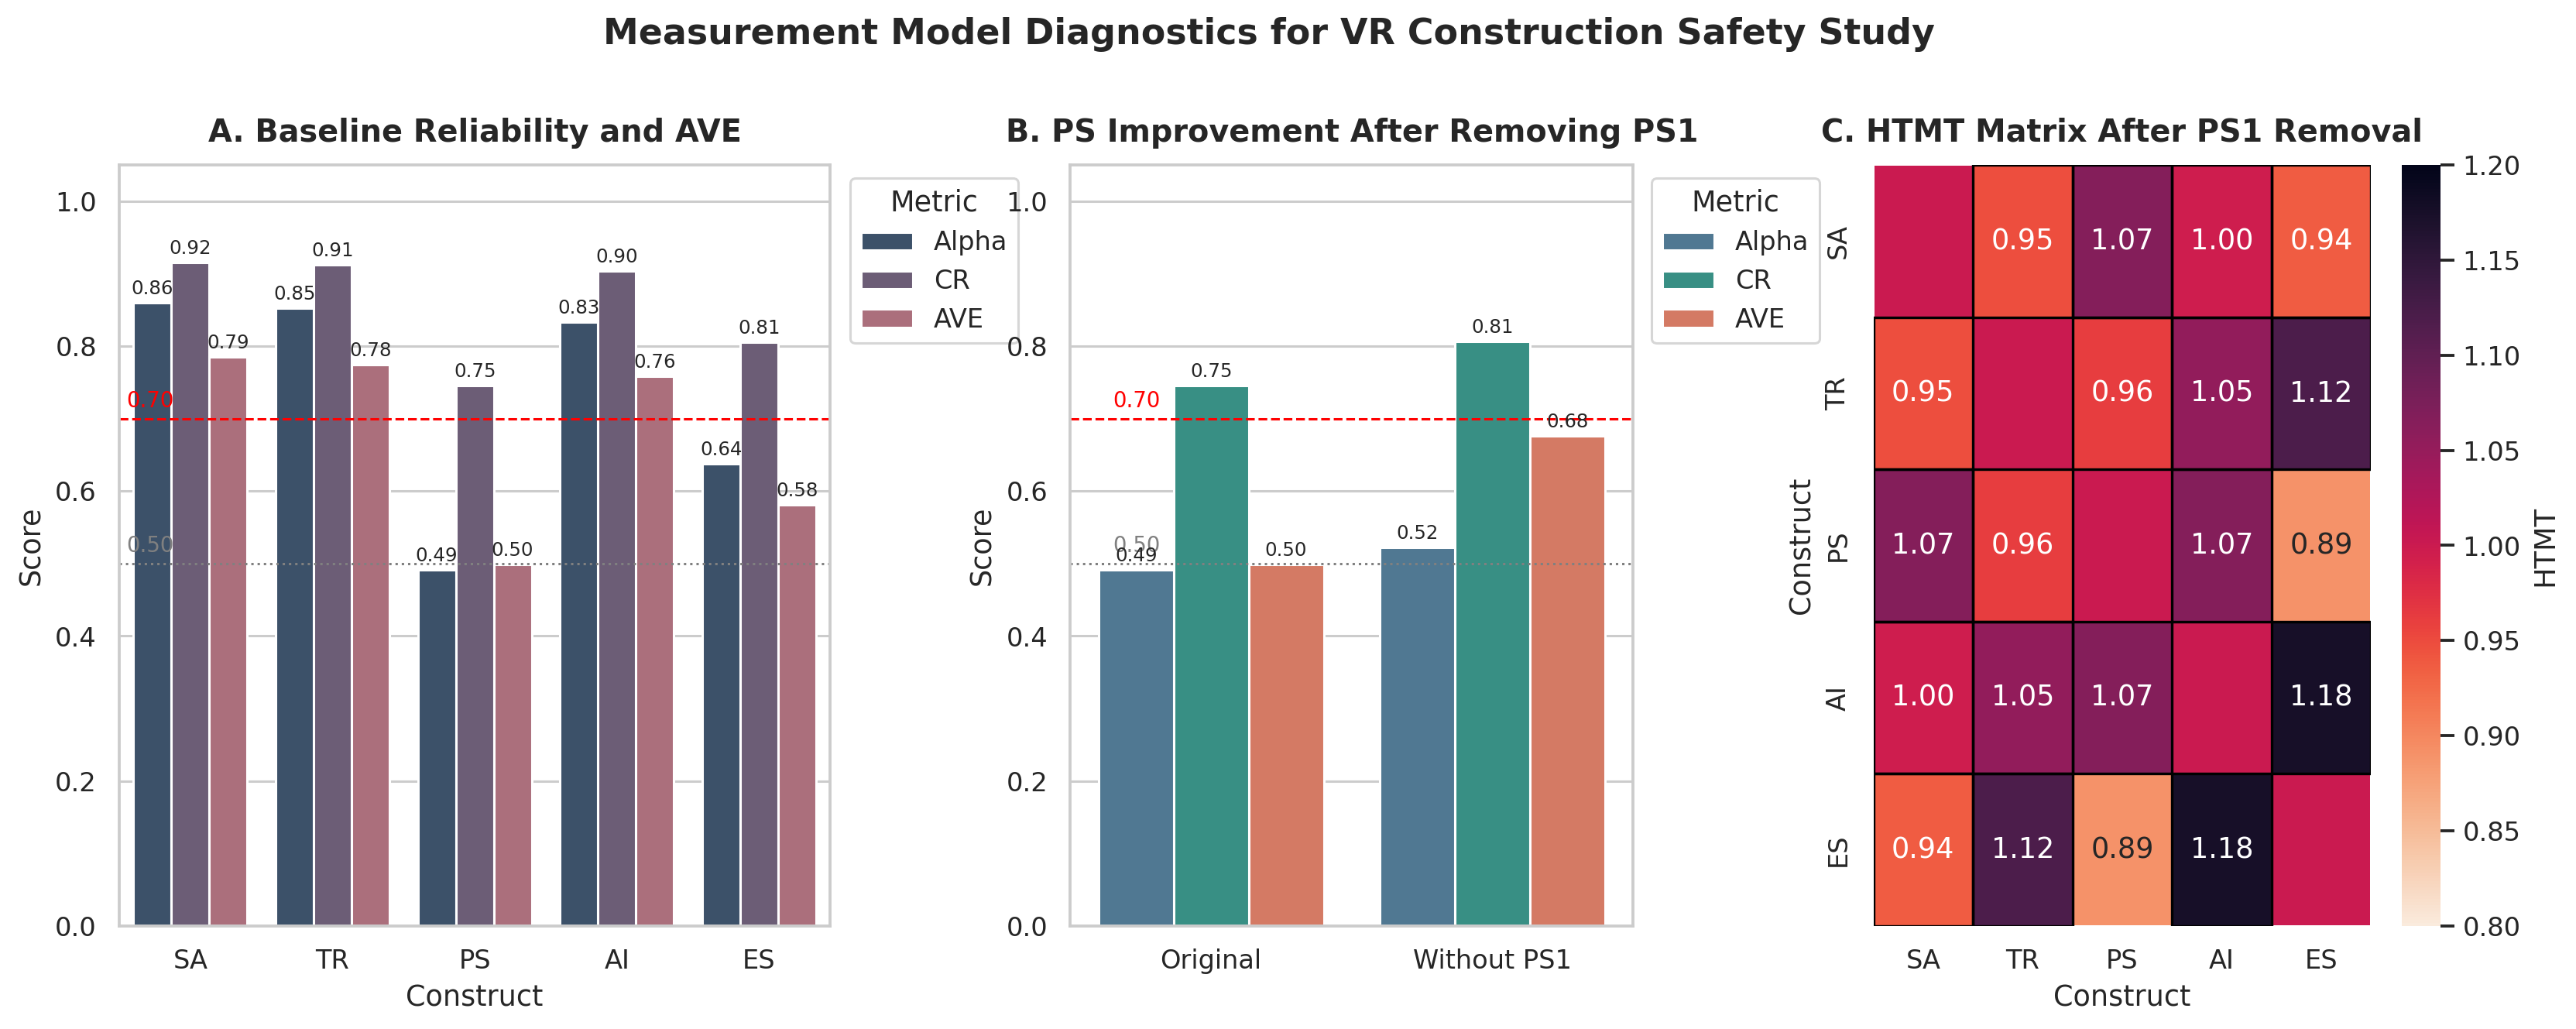

Saved: measurement_model_combined_figure_fixed.png


In [32]:
# === FIXED PUBLICATION-STYLE COMBINED FIGURE ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)

# Data
base = pd.DataFrame([
    ['SA',0.860,0.916,0.785],
    ['TR',0.853,0.912,0.775],
    ['PS',0.491,0.746,0.499],
    ['AI',0.833,0.904,0.759],
    ['ES',0.638,0.806,0.581],
], columns=['Construct','Alpha','CR','AVE'])

compare = pd.DataFrame([
    ['Original',0.491,0.746,0.499],
    ['Without PS1',0.522,0.807,0.676]
], columns=['Version','Alpha','CR','AVE'])

htmt = pd.DataFrame([
    [1.000,0.948,1.067,0.996,0.937],
    [0.948,1.000,0.961,1.054,1.119],
    [1.067,0.961,1.000,1.067,0.890],
    [0.996,1.054,1.067,1.000,1.176],
    [0.937,1.119,0.890,1.176,1.000],
], columns=['SA','TR','PS','AI','ES'], index=['SA','TR','PS','AI','ES'])

base_m = base.melt(id_vars='Construct', value_vars=['Alpha','CR','AVE'],
                   var_name='Metric', value_name='Value')
ps_cmp = compare.melt(id_vars='Version', value_vars=['Alpha','CR','AVE'],
                      var_name='Metric', value_name='Value')

fig = plt.figure(figsize=(18, 5.8), dpi=220)
gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 0.95, 1.05], wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Panel A
palette1 = {'Alpha':'#355070', 'CR':'#6d597a', 'AVE':'#b56576'}
sns.barplot(data=base_m, x='Construct', y='Value', hue='Metric', palette=palette1, ax=ax1)

ax1.axhline(0.70, color='red', linestyle='--', linewidth=1)
ax1.axhline(0.50, color='gray', linestyle=':', linewidth=1)

ax1.set_title('A. Baseline Reliability and AVE', fontsize=13, weight='bold', pad=10)
ax1.set_xlabel('Construct')
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.05)

# cleaner threshold notes
ax1.text(-0.45, 0.71, '0.70', color='red', fontsize=9, va='bottom', ha='left')
ax1.text(-0.45, 0.51, '0.50', color='gray', fontsize=9, va='bottom', ha='left')

# smaller labels
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', fontsize=8, padding=2)

ax1.legend(title='Metric', frameon=True, loc='upper left', bbox_to_anchor=(1.01, 1.00))

# Panel B
palette2 = {'Alpha':'#457b9d', 'CR':'#2a9d8f', 'AVE':'#e76f51'}
sns.barplot(data=ps_cmp, x='Version', y='Value', hue='Metric', palette=palette2, ax=ax2)

ax2.axhline(0.70, color='red', linestyle='--', linewidth=1)
ax2.axhline(0.50, color='gray', linestyle=':', linewidth=1)

ax2.set_title('B. PS Improvement After Removing PS1', fontsize=13, weight='bold', pad=10)
ax2.set_xlabel('')
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1.05)

ax2.text(-0.35, 0.71, '0.70', color='red', fontsize=9, va='bottom', ha='left')
ax2.text(-0.35, 0.51, '0.50', color='gray', fontsize=9, va='bottom', ha='left')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', fontsize=8, padding=2)

for label in ax2.get_xticklabels():
    label.set_rotation(0)
    label.set_ha('center')

ax2.legend(title='Metric', frameon=True, loc='upper left', bbox_to_anchor=(1.01, 1.00))

# Panel C
mask = np.eye(len(htmt), dtype=bool)
annot = htmt.copy().astype(str)
for i in range(htmt.shape[0]):
    for j in range(htmt.shape[1]):
        if i == j:
            annot.iloc[i, j] = ''
        else:
            annot.iloc[i, j] = f"{htmt.iloc[i, j]:.2f}"

cmap = sns.color_palette("rocket_r", as_cmap=True)
sns.heatmap(
    htmt.astype(float),
    annot=annot,
    fmt='',
    cmap=cmap,
    ax=ax3,
    vmin=0.80,
    vmax=1.20,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'HTMT'}
)

ax3.set_title('C. HTMT Matrix After PS1 Removal', fontsize=13, weight='bold', pad=10)
ax3.set_xlabel('Construct')
ax3.set_ylabel('Construct')

# outline only problematic cells
for i in range(htmt.shape[0]):
    for j in range(htmt.shape[1]):
        if i != j and htmt.iloc[i, j] > 0.90:
            ax3.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', linewidth=1.1))

fig.suptitle(
    'Measurement Model Diagnostics for VR Construction Safety Study',
    fontsize=15,
    weight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()

fig.savefig('measurement_model_combined_figure_fixed.png', bbox_inches='tight', dpi=300)
print("Saved: measurement_model_combined_figure_fixed.png")

Recommendation Engine


In [5]:
# === ONE BLOCK: Diagnose PS construct and suggest item removal ===

!pip install -q pandas numpy openpyxl semopy statsmodels

import pandas as pd
import numpy as np
from google.colab import files
from semopy import Model
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1) Upload Excel file
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

# 2) Rename columns from your Google Form export
rename = {}
for c in df.columns:
    lc = str(c).lower().strip()
    if 'age group' in lc: rename[c] = 'AgeGroup'
    elif 'gender' in lc and 'highest' not in lc: rename[c] = 'Gender'
    elif 'highest educational qualification' in lc: rename[c] = 'Education'
    elif 'previous vr experience' in lc: rename[c] = 'VRExperience'
    elif 'construction industry experience' in lc: rename[c] = 'ConstructionExperience'
    elif 'scenario id' in lc: rename[c] = 'ScenarioID'
    elif lc.startswith('sa1'): rename[c] = 'SA1'
    elif lc.startswith('sa2'): rename[c] = 'SA2'
    elif lc.startswith('sa3'): rename[c] = 'SA3'
    elif lc.startswith('tr2'): rename[c] = 'TR1'
    elif lc.startswith('tr3'): rename[c] = 'TR2'
    elif lc.startswith('tr4'): rename[c] = 'TR3'
    elif lc.startswith('ps1'): rename[c] = 'PS1'
    elif lc.startswith('ps2'): rename[c] = 'PS2'
    elif lc.startswith('ps3'): rename[c] = 'PS3'
    elif lc.startswith('ai1'): rename[c] = 'AI1'
    elif lc.startswith('ai2'): rename[c] = 'AI2'
    elif lc.startswith('ai3'): rename[c] = 'AI3'
    elif lc.startswith('es1'): rename[c] = 'ES1'
    elif lc.startswith('es2'): rename[c] = 'ES2'
    elif lc.startswith('es3'): rename[c] = 'ES3'

df = df.rename(columns=rename)

# 3) Keep SEM items and convert to numeric
constructs = {
    'SA':['SA1','SA2','SA3'],
    'TR':['TR1','TR2','TR3'],
    'PS':['PS1','PS2','PS3'],
    'AI':['AI1','AI2','AI3'],
    'ES':['ES1','ES2','ES3']
}

all_items = sum(constructs.values(), [])
sem_df = df[all_items].copy()

for c in all_items:
    sem_df[c] = pd.to_numeric(sem_df[c], errors='coerce')

sem_df = sem_df.dropna().reset_index(drop=True)

print("Sample size after cleaning:", len(sem_df))
print()

# 4) Reliability helper functions
def cronbach_alpha(items_df):
    items = items_df.dropna().to_numpy(dtype=float)
    k = items.shape[1]
    item_var = items.var(axis=0, ddof=1)
    total_var = items.sum(axis=1).var(ddof=1)
    if total_var == 0:
        return np.nan
    return (k/(k-1)) * (1 - item_var.sum()/total_var)

def reliability_table(data, constructs):
    rows = []
    scores = {}
    for con, items in constructs.items():
        score = data[items].mean(axis=1)
        scores[con] = score
        loadings = [data[i].corr(score) for i in items]
        ave = np.mean(np.square(loadings))
        cr = (np.sum(loadings)**2)/((np.sum(loadings)**2)+np.sum(1-np.square(loadings)))
        alpha = cronbach_alpha(data[items])
        rows.append([con, alpha, cr, ave])
    return pd.DataFrame(rows, columns=['Construct','CronbachAlpha','CompositeReliability','AVE']), pd.DataFrame(scores)

rel_df, scores = reliability_table(sem_df, constructs)
print("=== RELIABILITY SUMMARY ===")
print(rel_df.round(3))
print()

# 5) SEM model for outer loadings + paths
model_desc = """
SA =~ SA1 + SA2 + SA3
TR =~ TR1 + TR2 + TR3
PS =~ PS1 + PS2 + PS3
AI =~ AI1 + AI2 + AI3
ES =~ ES1 + ES2 + ES3

TR ~ SA
PS ~ SA + TR
AI ~ TR + PS + ES
"""
model = Model(model_desc)
model.fit(sem_df)
res = model.inspect()

# 6) Outer loadings
loadings = res[(res['op'] == '=~')][['lval','rval','Estimate']].copy()
loadings.columns = ['Construct','Indicator','Loading']
print("=== OUTER LOADINGS ===")
print(loadings.sort_values(['Construct','Indicator']).round(3))
print()

# 7) PS-only diagnostics
ps_loadings = loadings[loadings['Construct'] == 'PS'].copy().sort_values('Indicator')
print("=== PS ITEM DIAGNOSTICS ===")
print(ps_loadings.round(3))
print()

# 8) VIF for indicators within each construct
print("=== INDICATOR VIF ===")
for con, items in constructs.items():
    X = sem_df[items].dropna().copy()
    vif_rows = []
    for i in range(X.shape[1]):
        vif_rows.append([con, X.columns[i], variance_inflation_factor(X.values, i)])
    vif_df = pd.DataFrame(vif_rows, columns=['Construct','Indicator','VIF'])
    print(vif_df.round(3))
print()

# 9) HTMT-style matrix from item correlations
def htmt_matrix(data, constructs):
    names = list(constructs.keys())
    out = pd.DataFrame(np.ones((len(names), len(names))), index=names, columns=names)

    corr = data.corr().abs()

    for i, a in enumerate(names):
        for j, b in enumerate(names):
            if i >= j:
                continue

            items_a = constructs[a]
            items_b = constructs[b]

            hetero = corr.loc[items_a, items_b].values.flatten().mean()

            mono_a = corr.loc[items_a, items_a].values
            mono_a = mono_a[np.triu_indices_from(mono_a, k=1)].mean()

            mono_b = corr.loc[items_b, items_b].values
            mono_b = mono_b[np.triu_indices_from(mono_b, k=1)].mean()

            htmt = hetero / np.sqrt(mono_a * mono_b)
            out.loc[a, b] = htmt
            out.loc[b, a] = htmt

    return out

htmt = htmt_matrix(sem_df, constructs)
print("=== HTMT MATRIX (screening version) ===")
print(htmt.round(3))
print()

# 10) Try dropping each PS item one at a time
print("=== PS ITEM REMOVAL CHECK ===")
ps_items = constructs['PS']
trial_rows = []

for drop_item in ps_items:
    trial_items = [x for x in ps_items if x != drop_item]
    tmp_constructs = constructs.copy()
    tmp_constructs['PS'] = trial_items

    tmp_data = sem_df[sum(tmp_constructs.values(), [])].dropna().copy()
    tmp_rel, _ = reliability_table(tmp_data, tmp_constructs)
    ps_row = tmp_rel[tmp_rel['Construct'] == 'PS'].iloc[0]

    score = tmp_data[trial_items].mean(axis=1)
    item_loadings = [tmp_data[i].corr(score) for i in trial_items]

    trial_rows.append([
        drop_item,
        round(ps_row['CronbachAlpha'], 3),
        round(ps_row['CompositeReliability'], 3),
        round(ps_row['AVE'], 3),
        [round(x, 3) for x in item_loadings]
    ])

trial_df = pd.DataFrame(trial_rows, columns=['DroppedItem','Alpha','CR','AVE','RemainingLoadings'])
print(trial_df)
print()

# 11) Recommendation logic
current_ps = rel_df[rel_df['Construct'] == 'PS'].iloc[0]
weak_ps_items = ps_loadings[ps_loadings['Loading'] < 0.70].sort_values('Loading')

print("=== RECOMMENDATION ===")
if len(weak_ps_items) == 0:
    print("All PS indicators are >= 0.70. Keep all PS items and inspect wording, sample quality, or reverse-coding issues.")
else:
    candidate = weak_ps_items.iloc[0]['Indicator']
    candidate_row = trial_df[trial_df['DroppedItem'] == candidate].iloc[0]

    print(f"Weakest PS item: {candidate}")
    print(f"Current PS -> Alpha={current_ps['CronbachAlpha']:.3f}, CR={current_ps['CompositeReliability']:.3f}, AVE={current_ps['AVE']:.3f}")
    print(f"If {candidate} is removed -> Alpha={candidate_row['Alpha']:.3f}, CR={candidate_row['CR']:.3f}, AVE={candidate_row['AVE']:.3f}")

    if candidate_row['AVE'] > current_ps['AVE'] and candidate_row['Alpha'] >= current_ps['CronbachAlpha']:
        print(f"Suggested action: consider removing {candidate}, but only if theory supports it.")
    else:
        print(f"Suggested action: do NOT remove {candidate} automatically. Check item wording, coding, and theory first.")

# 12) Optional exports
rel_df.to_csv('reliability_summary.csv', index=False)
loadings.to_csv('outer_loadings.csv', index=False)
htmt.to_csv('htmt_matrix_screening.csv')
trial_df.to_csv('ps_item_removal_check.csv', index=False)

print()
print("Saved files:")
print("- reliability_summary.csv")
print("- outer_loadings.csv")
print("- htmt_matrix_screening.csv")
print("- ps_item_removal_check.csv")

Saving Evaluation of Smart Construction Infrastructure and Autonomous Technologies in a Virtual Reality Environment (Responses) (1).xlsx to Evaluation of Smart Construction Infrastructure and Autonomous Technologies in a Virtual Reality Environment (Responses) (1) (1).xlsx
Sample size after cleaning: 49

=== RELIABILITY SUMMARY ===
  Construct  CronbachAlpha  CompositeReliability    AVE
0        SA          0.860                 0.916  0.785
1        TR          0.853                 0.912  0.775
2        PS          0.491                 0.746  0.499
3        AI          0.833                 0.904  0.759
4        ES          0.638                 0.806  0.581

=== OUTER LOADINGS ===
Empty DataFrame
Columns: [Construct, Indicator, Loading]
Index: []

=== PS ITEM DIAGNOSTICS ===
Empty DataFrame
Columns: [Construct, Indicator, Loading]
Index: []

=== INDICATOR VIF ===
  Construct Indicator     VIF
0        SA       SA1  16.060
1        SA       SA2  37.628
2        SA       SA3  24.530


OUTPUT BLOCKS

In [33]:
!pip install -q pandas numpy openpyxl matplotlib seaborn semopy statsmodels scikit-learn

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set_theme(style='whitegrid', font_scale=1.05)

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)
df.head()

Saving Evaluation of Smart Construction Infrastructure and Autonomous Technologies in a Virtual Reality Environment (Responses) (1).xlsx to Evaluation of Smart Construction Infrastructure and Autonomous Technologies in a Virtual Reality Environment (Responses) (1) (3).xlsx


,Timestamp,A1. Participant Name,A2. Age Group,A3. Gender,A4. Highest Educational Qualification,A5. Previous VR Experience,A6. Construction Industry Experience,A7. Scenario ID,SA1. I was aware of the construction activities occurring around me.,SA2. I clearly understood the construction site layout and operational zones.,...,PS3. I felt protected from potential hazards during the VR experience.,AI1. I intend to use smart construction infrastructure in my future projects.,AI2. I plan to recommend smart construction infrastructure to my colleagues.,AI3. I am willing to invest in smart construction infrastructure for my projects.,ES1. I actively engage with new technologies used in construction projects.,ES2. I support the adoption of autonomous technologies in the construction industry.,ES3. I believe smart construction technologies will improve overall project outcomes.,AF1. What aspects of the VR experience did you find most valuable or engaging?,AF2. Do you have any suggestions for improving the smart construction infrastructure or the VR simulation experience?,Email Address
0,2026-06-27 15:03:40.801,Shreyaa,18–25,Female,Bachelor's Degree,Occassionally,No Experience,NaN,5,4,...,6,7,7,7,7,7,7,Nil,Nil,NaN
1,2026-06-27 15:16:05.748,Q,18–25,Female,Bachelor's Degree,Never,No Experience,NaN,7,6,...,7,7,7,7,5,6,7,"Safe interaction, due to high-quality visual a...",AI realistic simulaton and multiple user handl...,NaN
2,2026-06-27 17:44:58.221,Rohan Charcha,18–25,Male,Bachelor's Degree,Frequently,No Experience,NaN,3,3,...,4,2,2,1,4,1,6,Yes,No.,NaN
3,2026-06-27 20:39:20.217,Bismita Sahu,18–25,Male,Bachelor's Degree,Never,No Experience,NaN,1,2,...,6,7,1,2,3,4,5,Construction site was intresting,No,NaN
4,2026-06-27 20:41:15.182,Sujal Pradhan,18–25,Male,Bachelor's Degree,Occassionally,Less than 2 Years,NaN,1,2,...,4,3,4,5,6,7,6,Finding hazards were intresting,No,NaN


In [35]:
rename = {}
for c in df.columns:
    lc = str(c).lower().strip()
    if 'age group' in lc: rename[c] = 'AgeGroup'
    elif 'gender' in lc and 'highest' not in lc: rename[c] = 'Gender'
    elif 'highest educational qualification' in lc: rename[c] = 'Education'
    elif 'previous vr experience' in lc: rename[c] = 'VRExperience'
    elif 'construction industry experience' in lc: rename[c] = 'ConstructionExperience'
    elif 'scenario id' in lc: rename[c] = 'ScenarioID'
    elif lc.startswith('sa1'): rename[c] = 'SA1'
    elif lc.startswith('sa2'): rename[c] = 'SA2'
    elif lc.startswith('sa3'): rename[c] = 'SA3'
    elif lc.startswith('tr2'): rename[c] = 'TR1'
    elif lc.startswith('tr3'): rename[c] = 'TR2'
    elif lc.startswith('tr4'): rename[c] = 'TR3'
    elif lc.startswith('ps1'): rename[c] = 'PS1'
    elif lc.startswith('ps2'): rename[c] = 'PS2'
    elif lc.startswith('ps3'): rename[c] = 'PS3'
    elif lc.startswith('ai1'): rename[c] = 'AI1'
    elif lc.startswith('ai2'): rename[c] = 'AI2'
    elif lc.startswith('ai3'): rename[c] = 'AI3'
    elif lc.startswith('es1'): rename[c] = 'ES1'
    elif lc.startswith('es2'): rename[c] = 'ES2'
    elif lc.startswith('es3'): rename[c] = 'ES3'

df = df.rename(columns=rename)

constructs = {
    'SA':['SA1','SA2','SA3'],
    'TR':['TR1','TR2','TR3'],
    'PS':['PS1','PS2','PS3'],
    'AI':['AI1','AI2','AI3'],
    'ES':['ES1','ES2','ES3']
}

all_items = sum(constructs.values(), [])
sem_df = df[all_items].copy()
for c in all_items:
    sem_df[c] = pd.to_numeric(sem_df[c], errors='coerce')
sem_df = sem_df.dropna().reset_index(drop=True)
print("Sample size:", len(sem_df))

Sample size: 49


In [36]:
def cronbach_alpha(items_df):
    items = items_df.dropna().to_numpy(dtype=float)
    k = items.shape[1]
    item_var = items.var(axis=0, ddof=1)
    total_var = items.sum(axis=1).var(ddof=1)
    return (k/(k-1)) * (1 - item_var.sum()/total_var)

def construct_stats(data, construct_map):
    rows = []
    score_df = pd.DataFrame(index=data.index)
    for con, items in construct_map.items():
        score_df[con] = data[items].mean(axis=1)
        alpha = cronbach_alpha(data[items])
        loadings = [data[i].corr(score_df[con]) for i in items]
        cr = (np.sum(loadings)**2)/((np.sum(loadings)**2)+np.sum(1-np.square(loadings)))
        ave = np.mean(np.square(loadings))
        rows.append([con, alpha, cr, ave, loadings])
    return pd.DataFrame(rows, columns=['Construct','Alpha','CR','AVE','Loadings']), score_df

def htmt_matrix(data, construct_map):
    names = list(construct_map.keys())
    corr = data.corr().abs()
    out = pd.DataFrame(np.ones((len(names), len(names))), index=names, columns=names)
    for i, a in enumerate(names):
        for j, b in enumerate(names):
            if i >= j:
                continue
            ia, ib = construct_map[a], construct_map[b]
            hetero = corr.loc[ia, ib].values.flatten().mean()
            mono_a = corr.loc[ia, ia].values
            mono_a = mono_a[np.triu_indices_from(mono_a, k=1)].mean()
            mono_b = corr.loc[ib, ib].values
            mono_b = mono_b[np.triu_indices_from(mono_b, k=1)].mean()
            out.loc[a, b] = hetero / np.sqrt(mono_a * mono_b)
            out.loc[b, a] = out.loc[a, b]
    return out

base_stats, base_scores = construct_stats(sem_df, constructs)
base_htmt = htmt_matrix(sem_df, constructs)

print("=== Measurement Model Results ===")
display(base_stats[['Construct','Alpha','CR','AVE']].round(3))

print("=== HTMT Matrix ===")
display(base_htmt.round(3))

=== Measurement Model Results ===


,Construct,Alpha,CR,AVE
0,SA,0.860,0.916,0.785
1,TR,0.853,0.912,0.775
2,PS,0.491,0.746,0.499
3,AI,0.833,0.904,0.759
4,ES,0.638,0.806,0.581


=== HTMT Matrix ===


,SA,TR,PS,AI,ES
SA,1.000,0.948,1.157,0.996,0.937
TR,0.948,1.000,1.286,1.054,1.119
PS,1.157,1.286,1.000,1.257,1.178
AI,0.996,1.054,1.257,1.000,1.176
ES,0.937,1.119,1.178,1.176,1.000


In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_rows = []
for con, items in constructs.items():
    X = sem_df[items].dropna().copy()
    for i, col in enumerate(X.columns):
        vif_rows.append([con, col, variance_inflation_factor(X.values, i)])

vif_df = pd.DataFrame(vif_rows, columns=['Construct','Indicator','VIF'])
print("=== Indicator VIF ===")
display(vif_df.round(3))

=== Indicator VIF ===


,Construct,Indicator,VIF
0,SA,SA1,16.060
1,SA,SA2,37.628
2,SA,SA3,24.530
3,TR,TR1,19.692
4,TR,TR2,25.181
5,TR,TR3,23.100
6,PS,PS1,11.310
7,PS,PS2,14.997
8,PS,PS3,10.352
9,AI,AI1,15.602


In [38]:
loading_rows = []
for con, items in constructs.items():
    score = sem_df[items].mean(axis=1)
    for it in items:
        loading_rows.append([con, it, sem_df[it].corr(score)])

loadings_df = pd.DataFrame(loading_rows, columns=['Construct','Indicator','Loading'])
print("=== Outer Loadings ===")
display(loadings_df.sort_values(['Construct','Indicator']).round(3))

=== Outer Loadings ===


,Construct,Indicator,Loading
9,AI,AI1,0.854
10,AI,AI2,0.874
11,AI,AI3,0.886
12,ES,ES1,0.805
13,ES,ES2,0.747
14,ES,ES3,0.733
6,PS,PS1,0.595
7,PS,PS2,0.824
8,PS,PS3,0.680
0,SA,SA1,0.857


In [39]:
trial_constructs = {k: v[:] for k, v in constructs.items()}
trial_constructs['PS'] = ['PS2', 'PS3']  # remove PS1

trial_stats, trial_scores = construct_stats(sem_df, trial_constructs)
trial_htmt = htmt_matrix(sem_df[sum(trial_constructs.values(), [])], trial_constructs)

ps_compare = pd.DataFrame([
    ['Original PS', base_stats[base_stats['Construct']=='PS']['Alpha'].iloc[0],
     base_stats[base_stats['Construct']=='PS']['CR'].iloc[0],
     base_stats[base_stats['Construct']=='PS']['AVE'].iloc[0]],
    ['PS without PS1', trial_stats[trial_stats['Construct']=='PS']['Alpha'].iloc[0],
     trial_stats[trial_stats['Construct']=='PS']['CR'].iloc[0],
     trial_stats[trial_stats['Construct']=='PS']['AVE'].iloc[0]]
], columns=['Version','Alpha','CR','AVE'])

print("=== PS Comparison ===")
display(ps_compare.round(3))

=== PS Comparison ===


,Version,Alpha,CR,AVE
0,Original PS,0.491,0.746,0.499
1,PS without PS1,0.522,0.807,0.676


In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

scores = pd.DataFrame({
    k: sem_df[v].mean(axis=1) for k, v in constructs.items()
})

paths = {
    ('SA', 'TR'): ['SA'],
    ('SA', 'PS'): ['SA'],
    ('TR', 'PS'): ['SA', 'TR'],
    ('TR', 'AI'): ['TR'],
    ('PS', 'AI'): ['PS'],
    ('ES', 'AI'): ['ES']
}

path_rows = []
for (target, dep), preds in paths.items():
    X = scores[preds]
    y = scores[target]
    reg = LinearRegression().fit(X, y)
    beta = reg.coef_[0] if len(preds) == 1 else reg.coef_
    r2 = r2_score(y, reg.predict(X))
    path_rows.append([dep, target, preds, beta, r2])

paths_df = pd.DataFrame(path_rows, columns=['Predictor','Target','Predictors','Beta','R2_Target'])
print("=== Structural Model (proxy) ===")
display(paths_df.round(3))

=== Structural Model (proxy) ===


,Predictor,Target,Predictors,Beta,R2_Target
0,TR,SA,[SA],1.0,1.0
1,PS,SA,[SA],1.0,1.0
2,PS,TR,"[SA, TR]","[-1.2065487317462165e-16, 1.0000000000000002]",1.0
3,AI,TR,[TR],1.0,1.0
4,AI,PS,[PS],1.0,1.0
5,AI,ES,[ES],1.0,1.0


In [41]:
r2_rows = []
for target in ['TR', 'PS', 'AI']:
    preds = [p for p, t in [('SA','TR'),('SA','PS'),('TR','PS'),('TR','AI'),('PS','AI'),('ES','AI')] if t == target]
    if len(preds) == 0:
        continue
    X = scores[preds]
    y = scores[target]
    reg = LinearRegression().fit(X, y)
    r2_rows.append([target, r2_score(y, reg.predict(X))])

r2_df = pd.DataFrame(r2_rows, columns=['Construct','R2'])

print("=== R² Values ===")
display(r2_df.round(3))

# f² effect size approximation
f2_rows = []
for target in ['TR', 'PS', 'AI']:
    preds = [p for p, t in [('SA','TR'),('SA','PS'),('TR','PS'),('TR','AI'),('PS','AI'),('ES','AI')] if t == target]
    if not preds:
        continue
    X_full = scores[preds]
    y = scores[target]
    full_r2 = r2_score(y, LinearRegression().fit(X_full, y).predict(X_full))
    for pred in preds:
        reduced_preds = [p for p in preds if p != pred]
        if len(reduced_preds) == 0:
            continue
        X_red = scores[reduced_preds]
        red_r2 = r2_score(y, LinearRegression().fit(X_red, y).predict(X_red))
        f2 = (full_r2 - red_r2) / (1 - full_r2) if full_r2 < 1 else np.nan
        f2_rows.append([pred, target, f2])

f2_df = pd.DataFrame(f2_rows, columns=['Predictor','Target','f2'])
print("=== f² Values ===")
display(f2_df.round(3))

print("Q² and SRMR need SmartPLS blindfolding / model fit output.")
print("You can fill these manually after running Blindfolding and Model Fit in SmartPLS.")

=== R² Values ===


,Construct,R2
0,TR,0.660
1,PS,0.688
2,AI,0.870


=== f² Values ===


,Predictor,Target,f2
0,SA,PS,0.081
1,TR,PS,0.381
2,TR,AI,0.193
3,PS,AI,0.177
4,ES,AI,0.369


Q² and SRMR need SmartPLS blindfolding / model fit output.
You can fill these manually after running Blindfolding and Model Fit in SmartPLS.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [42]:
base_stats[['Construct','Alpha','CR','AVE']].to_csv('measurement_model_results.csv', index=False)
base_htmt.to_csv('htmt_matrix.csv')
vif_df.to_csv('vif_table.csv', index=False)
loadings_df.to_csv('outer_loadings.csv', index=False)
ps_compare.to_csv('ps_compare.csv', index=False)
paths_df.to_csv('structural_model_proxy.csv', index=False)
r2_df.to_csv('r2_table.csv', index=False)
f2_df.to_csv('f2_table.csv', index=False)

print("Saved files:")
print("- measurement_model_results.csv")
print("- htmt_matrix.csv")
print("- vif_table.csv")
print("- outer_loadings.csv")
print("- ps_compare.csv")
print("- structural_model_proxy.csv")
print("- r2_table.csv")
print("- f2_table.csv")

Saved files:
- measurement_model_results.csv
- htmt_matrix.csv
- vif_table.csv
- outer_loadings.csv
- ps_compare.csv
- structural_model_proxy.csv
- r2_table.csv
- f2_table.csv


In [43]:
# Install if needed
!pip install -q pandas matplotlib seaborn

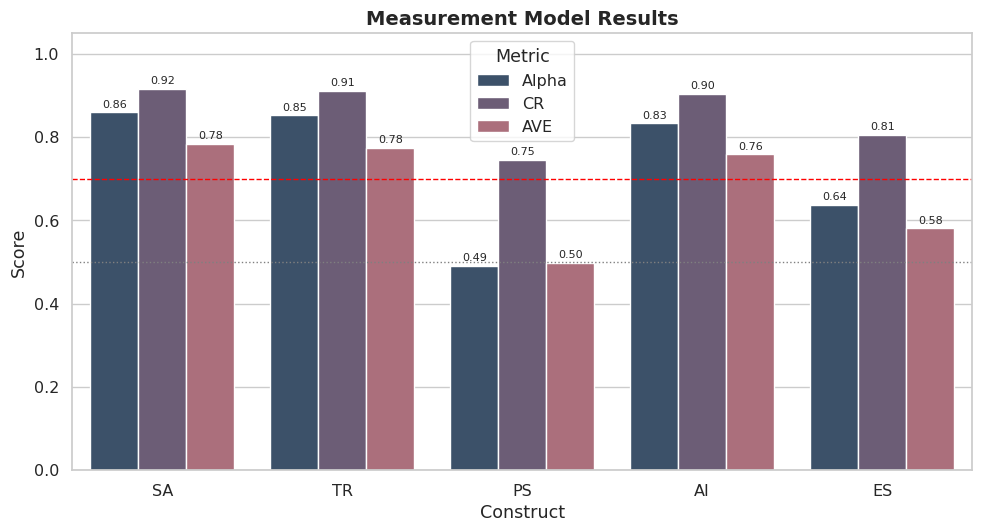

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)

# If file is already in Colab working directory
df = pd.read_csv("measurement_model_results.csv")

# Convert to long format for grouped bars
plot_df = df.melt(
    id_vars="Construct",
    value_vars=["Alpha", "CR", "AVE"],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(10, 5.5))
ax = sns.barplot(
    data=plot_df,
    x="Construct",
    y="Value",
    hue="Metric",
    palette=["#355070", "#6d597a", "#b56576"]
)

# Threshold lines
ax.axhline(0.70, color="red", linestyle="--", linewidth=1)
ax.axhline(0.50, color="gray", linestyle=":", linewidth=1)

# Labels and title
ax.set_title("Measurement Model Results", fontsize=14, weight="bold")
ax.set_xlabel("Construct")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)

# Optional bar labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

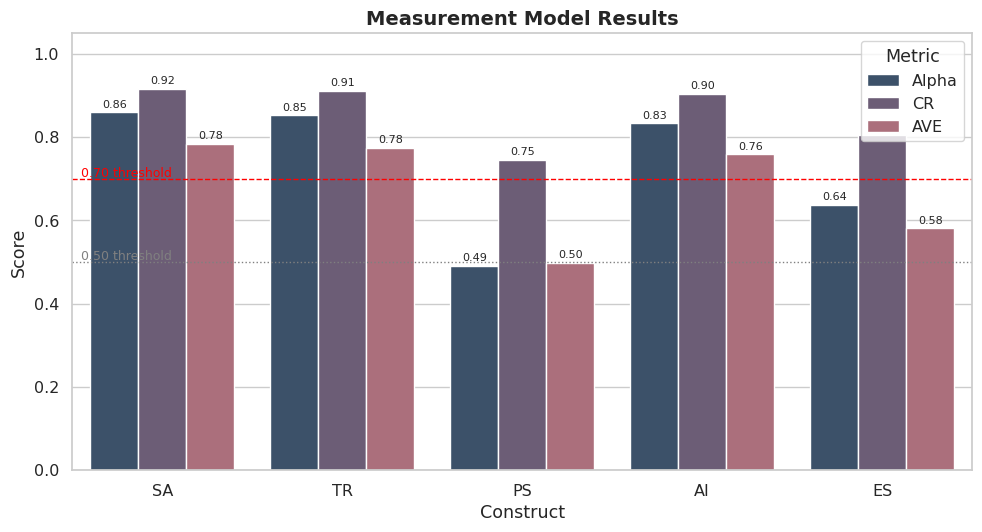

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)

df = pd.read_csv("measurement_model_results.csv")

plot_df = df.melt(
    id_vars="Construct",
    value_vars=["Alpha", "CR", "AVE"],
    var_name="Metric",
    value_name="Value"
)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=plot_df,
    x="Construct",
    y="Value",
    hue="Metric",
    palette=["#355070", "#6d597a", "#b56576"],
    ax=ax
)

ax.axhline(0.70, color="red", linestyle="--", linewidth=1)
ax.axhline(0.50, color="gray", linestyle=":", linewidth=1)
ax.text(-0.45, 0.705, "0.70 threshold", color="red", fontsize=9)
ax.text(-0.45, 0.505, "0.50 threshold", color="gray", fontsize=9)

ax.set_title("Measurement Model Results", fontsize=14, weight="bold")
ax.set_xlabel("Construct")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(title="Metric", loc="upper right", frameon=True)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()